**Importing Necessary Libraries**

In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from mlxtend.frequent_patterns import apriori, association_rules

# **Task 1: Data Cleaning and Preparation**

In [85]:
df = pd.read_csv('/content/Amazon.csv',skipinitialspace = True)
df.head()

,Timestamp,age,Gender,Purchase_Frequency,Purchase_Categories,Personalized_Recommendation_Frequency,Browsing_Frequency,Product_Search_Method,Search_Result_Exploration,Customer_Reviews_Importance,...,Review_Left,Review_Reliability,Review_Helpfulness,Personalized_Recommendation_Frequency,Recommendation_Helpfulness,Rating_Accuracy,Shopping_Satisfaction,Service_Appreciation,Improvement_Areas,transaction
0,2023/06/08 7:50:55 PM GMT+5:30,65,Prefer not to say,Less than once a month,Clothing and Fashion,Yes,Multiple times a day,Keyword,Multiple pages,2,...,Yes,Moderately,No,2,Sometimes,4,4,Competitive prices,better app interface and lower shipping charges,778242
1,2023/06/09 9:37:44 AM GMT+5:30,20,Male,Once a week,Groceries and Gourmet Food;Beauty and Personal...,No,Rarely,Filter,First page,3,...,Yes,Heavily,Yes,1,Sometimes,4,5,Quick delivery,Scrolling option would be much better than goi...,193482
2,2023/06/11 11:26:54 PM GMT+5:30,42,Male,Once a week,Groceries and Gourmet Food;Beauty and Personal...,Sometimes,Few times a week,Keyword,Multiple pages,2,...,Yes,Heavily,Sometimes,5,No,5,3,All the above,Nil,925975
3,2023/06/08 5:17:10 PM GMT+5:30,65,Others,Once a month,Beauty and Personal Care;Clothing and Fashion;...,No,Few times a month,Filter,Multiple pages,2,...,Yes,Occasionally,No,3,Yes,1,2,Quick delivery,Quality of product is very poor according to t...,566872
4,2023/06/11 10:59:30 PM GMT+5:30,45,Female,Once a week,Beauty and Personal Care;Clothing and Fashion;...,Sometimes,Few times a month,NaN,First page,5,...,Yes,Rarely,No,2,Yes,1,2,Quick delivery,Irrelevant product suggestions,683642


In [86]:
df.shape

(800, 24)

In [87]:
df.duplicated().sum()

np.int64(0)

In [88]:
df.isnull().sum()

,0
Timestamp,0
age,0
Gender,0
Purchase_Frequency,0
Purchase_Categories,0
Personalized_Recommendation_Frequency,0
Browsing_Frequency,0
Product_Search_Method,157
Search_Result_Exploration,0
Customer_Reviews_Importance,0


In [89]:
df.drop_duplicates(inplace=True)
df.head()

,Timestamp,age,Gender,Purchase_Frequency,Purchase_Categories,Personalized_Recommendation_Frequency,Browsing_Frequency,Product_Search_Method,Search_Result_Exploration,Customer_Reviews_Importance,...,Review_Left,Review_Reliability,Review_Helpfulness,Personalized_Recommendation_Frequency,Recommendation_Helpfulness,Rating_Accuracy,Shopping_Satisfaction,Service_Appreciation,Improvement_Areas,transaction
0,2023/06/08 7:50:55 PM GMT+5:30,65,Prefer not to say,Less than once a month,Clothing and Fashion,Yes,Multiple times a day,Keyword,Multiple pages,2,...,Yes,Moderately,No,2,Sometimes,4,4,Competitive prices,better app interface and lower shipping charges,778242
1,2023/06/09 9:37:44 AM GMT+5:30,20,Male,Once a week,Groceries and Gourmet Food;Beauty and Personal...,No,Rarely,Filter,First page,3,...,Yes,Heavily,Yes,1,Sometimes,4,5,Quick delivery,Scrolling option would be much better than goi...,193482
2,2023/06/11 11:26:54 PM GMT+5:30,42,Male,Once a week,Groceries and Gourmet Food;Beauty and Personal...,Sometimes,Few times a week,Keyword,Multiple pages,2,...,Yes,Heavily,Sometimes,5,No,5,3,All the above,Nil,925975
3,2023/06/08 5:17:10 PM GMT+5:30,65,Others,Once a month,Beauty and Personal Care;Clothing and Fashion;...,No,Few times a month,Filter,Multiple pages,2,...,Yes,Occasionally,No,3,Yes,1,2,Quick delivery,Quality of product is very poor according to t...,566872
4,2023/06/11 10:59:30 PM GMT+5:30,45,Female,Once a week,Beauty and Personal Care;Clothing and Fashion;...,Sometimes,Few times a month,NaN,First page,5,...,Yes,Rarely,No,2,Yes,1,2,Quick delivery,Irrelevant product suggestions,683642


In [90]:
# stripping column names:
df.columns = df.columns.str.strip()

In [91]:
# Standardizing categorical variables:
df['Gender'] = df['Gender'].str.strip().str.title().replace({'M':'Male','F':'Female','Prefer not to say':'Prefer not to say'})

In [92]:

# For frequency fields (e.g., Purchase_Frequency) mapping text → numeric scale:

freq_map = {'Less than once a month':0,'Once a month':1,'Few times a month':2,'Once a week':3,'Multiple times a week':4}
df['Purchase_Frequency_num'] = df['Purchase_Frequency'].map(freq_map)

In [93]:
for i, col in enumerate(df.columns):
    if col == "Personalized_Recommendation_Frequency" and df.iloc[:, i].dtype != 'O':
        print("Index of integer version of Personalized_Recommendation_Frequency:", i)

Index of integer version of Personalized_Recommendation_Frequency: 17


In [94]:
cols = list(df.columns)
cols[17] = "Personalized_Recommendation_Frequency_num"
df.columns = cols

In [95]:
df.head()

,Timestamp,age,Gender,Purchase_Frequency,Purchase_Categories,Personalized_Recommendation_Frequency,Browsing_Frequency,Product_Search_Method,Search_Result_Exploration,Customer_Reviews_Importance,...,Review_Reliability,Review_Helpfulness,Personalized_Recommendation_Frequency_num,Recommendation_Helpfulness,Rating_Accuracy,Shopping_Satisfaction,Service_Appreciation,Improvement_Areas,transaction,Purchase_Frequency_num
0,2023/06/08 7:50:55 PM GMT+5:30,65,Prefer Not To Say,Less than once a month,Clothing and Fashion,Yes,Multiple times a day,Keyword,Multiple pages,2,...,Moderately,No,2,Sometimes,4,4,Competitive prices,better app interface and lower shipping charges,778242,0
1,2023/06/09 9:37:44 AM GMT+5:30,20,Male,Once a week,Groceries and Gourmet Food;Beauty and Personal...,No,Rarely,Filter,First page,3,...,Heavily,Yes,1,Sometimes,4,5,Quick delivery,Scrolling option would be much better than goi...,193482,3
2,2023/06/11 11:26:54 PM GMT+5:30,42,Male,Once a week,Groceries and Gourmet Food;Beauty and Personal...,Sometimes,Few times a week,Keyword,Multiple pages,2,...,Heavily,Sometimes,5,No,5,3,All the above,Nil,925975,3
3,2023/06/08 5:17:10 PM GMT+5:30,65,Others,Once a month,Beauty and Personal Care;Clothing and Fashion;...,No,Few times a month,Filter,Multiple pages,2,...,Occasionally,No,3,Yes,1,2,Quick delivery,Quality of product is very poor according to t...,566872,1
4,2023/06/11 10:59:30 PM GMT+5:30,45,Female,Once a week,Beauty and Personal Care;Clothing and Fashion;...,Sometimes,Few times a month,NaN,First page,5,...,Rarely,No,2,Yes,1,2,Quick delivery,Irrelevant product suggestions,683642,3


In [96]:
# Handling missing values:
# By replacing the blank row in the numeric columns with that particular column's median

nums = ['Customer_Reviews_Importance','Shopping_Satisfaction','Rating_Accuracy']
for col in nums:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col] = df[col].fillna(df[col].median())


In [97]:
# Now proceeding with filling missing values for remaining categorical columns
cat_cols = df.select_dtypes(include='object').columns.tolist()

# Fill missing values in each categorical column iteratively.
for col in cat_cols:
    df[col] = df[col].fillna('Unknown')

In [98]:
df.head()

,Timestamp,age,Gender,Purchase_Frequency,Purchase_Categories,Personalized_Recommendation_Frequency,Browsing_Frequency,Product_Search_Method,Search_Result_Exploration,Customer_Reviews_Importance,...,Review_Reliability,Review_Helpfulness,Personalized_Recommendation_Frequency_num,Recommendation_Helpfulness,Rating_Accuracy,Shopping_Satisfaction,Service_Appreciation,Improvement_Areas,transaction,Purchase_Frequency_num
0,2023/06/08 7:50:55 PM GMT+5:30,65,Prefer Not To Say,Less than once a month,Clothing and Fashion,Yes,Multiple times a day,Keyword,Multiple pages,2,...,Moderately,No,2,Sometimes,4,4,Competitive prices,better app interface and lower shipping charges,778242,0
1,2023/06/09 9:37:44 AM GMT+5:30,20,Male,Once a week,Groceries and Gourmet Food;Beauty and Personal...,No,Rarely,Filter,First page,3,...,Heavily,Yes,1,Sometimes,4,5,Quick delivery,Scrolling option would be much better than goi...,193482,3
2,2023/06/11 11:26:54 PM GMT+5:30,42,Male,Once a week,Groceries and Gourmet Food;Beauty and Personal...,Sometimes,Few times a week,Keyword,Multiple pages,2,...,Heavily,Sometimes,5,No,5,3,All the above,Nil,925975,3
3,2023/06/08 5:17:10 PM GMT+5:30,65,Others,Once a month,Beauty and Personal Care;Clothing and Fashion;...,No,Few times a month,Filter,Multiple pages,2,...,Occasionally,No,3,Yes,1,2,Quick delivery,Quality of product is very poor according to t...,566872,1
4,2023/06/11 10:59:30 PM GMT+5:30,45,Female,Once a week,Beauty and Personal Care;Clothing and Fashion;...,Sometimes,Few times a month,Unknown,First page,5,...,Rarely,No,2,Yes,1,2,Quick delivery,Irrelevant product suggestions,683642,3


In [99]:
# Fixing inconsistent formats in Product_Search_Method:

import re

df['Product_Search_Method'] = df['Product_Search_Method'].fillna('unknown').apply(lambda x: [i.strip().lower() for i in re.split('[,;]', str(x))])

In [100]:
# Removing inconsistent survey responses:
# e.g., Age unrealistic (<10 or >100) ----> setting Nan or Dropping it

df.loc[(df['age']<12) | (df['age']>100),'age'] = np.nan
df['age'] = df['age'].fillna(df['age'].median())

# **Task 2: Descriptive Behavior Analysis**

In [101]:
# Summarizing customer demographics (age, gender distribution):

age_stats = df['age'].describe()
gender_counts = df['Gender'].value_counts(normalize = True)*100
print(age_stats,"\n")
print(gender_counts)

count    800.000000
mean      39.925000
std       15.056735
min       12.000000
25%       28.000000
50%       41.000000
75%       51.000000
max       67.000000
Name: age, dtype: float64 

Gender
Male                 26.125
Others               25.250
Female               24.625
Prefer Not To Say    24.000
Name: proportion, dtype: float64


In [102]:
# Analyzing overall purchase frequency and most popular product categories:

freq_counts = df['Purchase_Frequency'].value_counts()
top_categories = df['Purchase_Categories'].str.split(r'[,;]').explode().str.strip().head(10)
print(f"Frequency of Purchase:\n{freq_counts}\n")
print(f"Top 10 Categories:\n{top_categories}")

Frequency of Purchase:
Purchase_Frequency
Once a month              168
Multiple times a week     159
Once a week               159
Few times a month         158
Less than once a month    156
Name: count, dtype: int64

Top 10 Categories:
0          Clothing and Fashion
1    Groceries and Gourmet Food
1      Beauty and Personal Care
1              Home and Kitchen
2    Groceries and Gourmet Food
2      Beauty and Personal Care
2          Clothing and Fashion
2                        others
3      Beauty and Personal Care
3          Clothing and Fashion
Name: Purchase_Categories, dtype: object


In [103]:
# Identifying top browsing methods and most common cart abandonment factors:

# Top browsing methods:
browsing_methods = df['Product_Search_Method'].explode().value_counts().head(10)

# Cart abondonment factors:
abandonment_factors = df.Cart_Abandonment_Factors.str.split(',').explode().value_counts()

print(f"Top Browsing Methods:\n{browsing_methods}\n")
print(f"Cart Abandonment Factors:\n{abandonment_factors}")

Top Browsing Methods:
Product_Search_Method
keyword       170
categories    163
filter        161
unknown       157
others        149
Name: count, dtype: int64

Cart Abandonment Factors:
Cart_Abandonment_Factors
High shipping costs                           224
Found a better price elsewhere                206
Changed my mind or no longer need the item    194
others                                        176
Name: count, dtype: int64


In [104]:
# Calculating mean and median satisfaction, recommendation helpfulness, and rating
# accuracy for numeric columns:

metrics = ['Shopping_Satisfaction','Recommendation_Helpfulness','Rating_Accuracy']

# Identify numeric columns from the metrics list
numeric_metrics = [col for col in metrics if pd.api.types.is_numeric_dtype(df[col])]

# Perform aggregation only on numeric columns
if numeric_metrics:
    print(df[numeric_metrics].agg(['mean','median','std']).T)
else:
    print("No numeric columns found for aggregation in the selected metrics.")

# To analyze Recommendation_Helpfulness, which is categorical, using value_counts()
print("\nRecommendation Helpfulness Distribution:")
print(df['Recommendation_Helpfulness'].value_counts())

                          mean  median       std
Shopping_Satisfaction  3.01250     3.0  1.407060
Rating_Accuracy        2.96875     3.0  1.403651

Recommendation Helpfulness Distribution:
Recommendation_Helpfulness
Yes          270
Sometimes    268
No           262
Name: count, dtype: int64


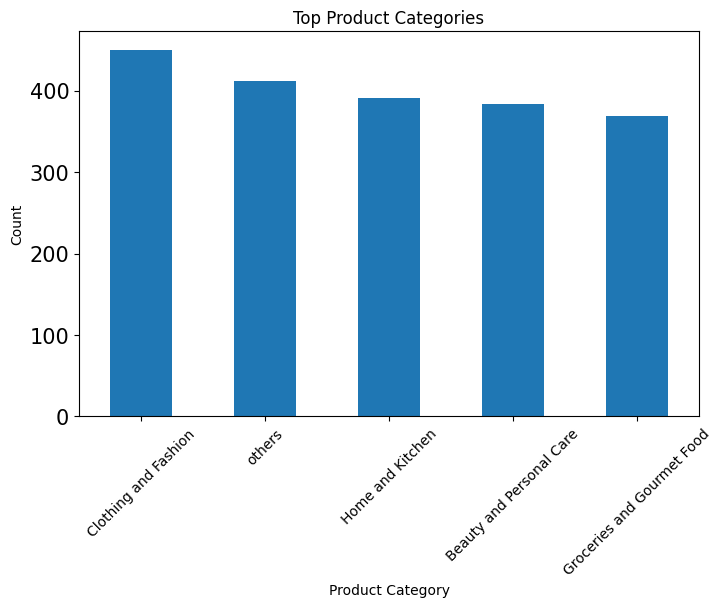

In [105]:
# Summary statistics and visualizations for key behavioral variables:

# Barplot for Top Product Categories:

plt.figure(figsize=(8,5))
# Calculate value counts for top categories
top_categories_counts = df['Purchase_Categories'].str.split(r'[,;]').explode().str.strip().value_counts().head(10)
top_categories_counts.plot(kind='bar')
plt.title("Top Product Categories")
plt.ylabel("Count")
plt.xlabel("Product Category")
plt.xticks(rotation=45)
plt.show()

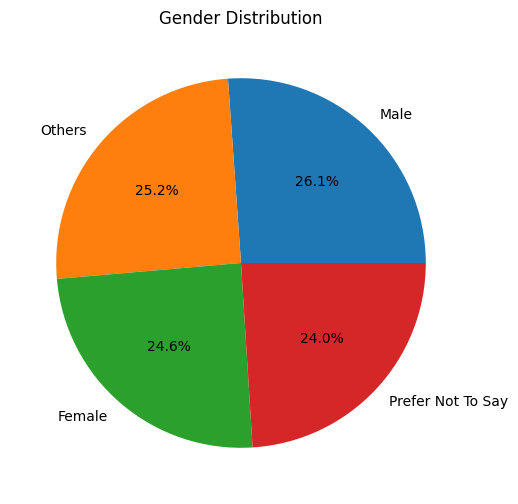

In [106]:
# Pie Chart for gender Distribution:
plt.figure(figsize=(6,6))
plt.pie(df.Gender.value_counts(), labels=df.Gender.value_counts().keys(), autopct='%1.1f%%')
plt.title('Gender Distribution')
plt.show()

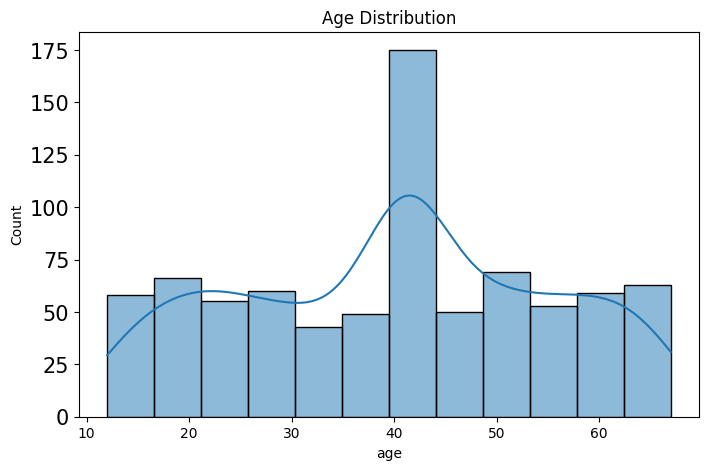

In [107]:
# Visualizing Age Distribution using a Histogram:

plt.figure(figsize=(8,5))
sns.histplot(df['age'], kde=True)
plt.title('Age Distribution')
plt.show()

Text(0.5, 1.0, 'Shopping Satisfaction')

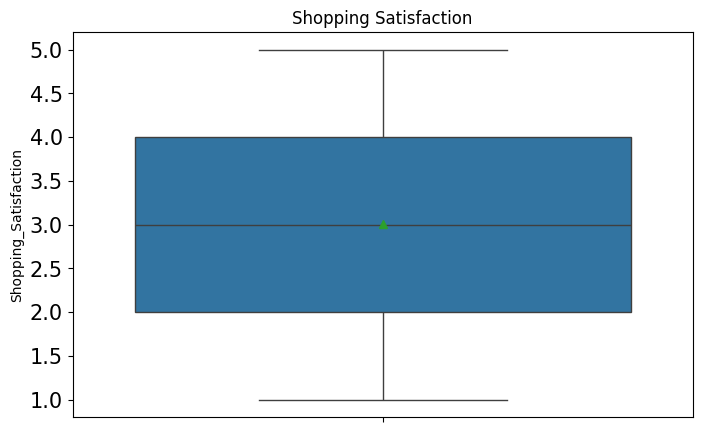

In [108]:
# Calculating customer shopping satisfaction:

plt.figure(figsize=(8,5))
sns.boxplot(df.Shopping_Satisfaction,showmeans = True)
plt.title('Shopping Satisfaction')

# **Task 3: Customer Segmentation and Profiling**

In [109]:
# Creating profiles as:
# ○ Frequent Buyers: High purchase frequency, high satisfaction.
# ○ Occasional Shoppers: Medium frequency, moderate satisfaction.
# ○ At-Risk Customers: Low satisfaction or frequent cart abandonment.

def rule_segment(row):
    if row['Purchase_Frequency_num'] >= 4 and row['Shopping_Satisfaction']>=4:
        return 'Frequent Buyer'
    elif row['Purchase_Frequency_num'] >=2:
        return 'Occasional'
    else:
        return 'At-Risk'
df['Segment_rule'] = df.apply(rule_segment, axis=1)
df[['Purchase_Frequency_num','Shopping_Satisfaction','Segment_rule']].head(10)

,Purchase_Frequency_num,Shopping_Satisfaction,Segment_rule
0,0,4,At-Risk
1,3,5,Occasional
2,3,3,Occasional
3,1,2,At-Risk
4,3,2,Occasional
5,2,3,Occasional
6,2,3,Occasional
7,2,1,Occasional
8,0,2,At-Risk
9,2,3,Occasional


   Purchase_Frequency_num  Shopping_Satisfaction  Customer_Reviews_Importance
0                       0                      4                            2
1                       3                      5                            3
2                       3                      3                            2
3                       1                      2                            2
4                       3                      2                            5


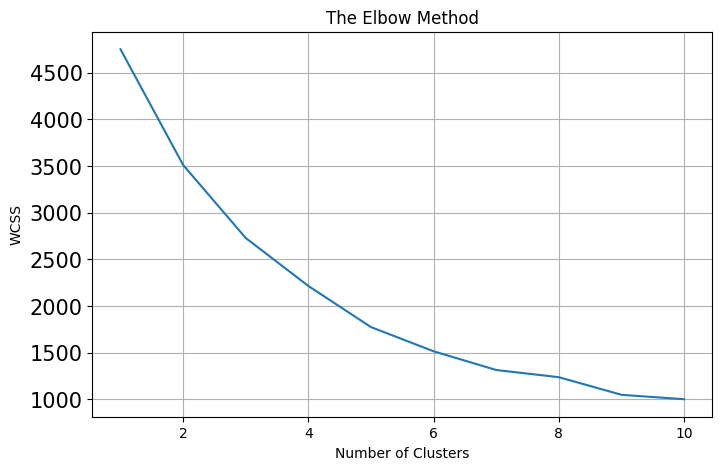

In [110]:
# Clustering (e.g., K-Means) for behavioral grouping based on survey responses:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

x = df[['Purchase_Frequency_num','Shopping_Satisfaction','Customer_Reviews_Importance']].fillna(0)
print(x.head())

wcss = []
for i in range(1,11):
  m = KMeans(n_clusters=i,random_state = 42)
  m.fit(x)
  wcss.append(m.inertia_)

plt.figure(figsize=(8,5))
plt.plot(list(range(1,11)),wcss)
plt.grid()
plt.title('The Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [111]:
# Calculating the Silhouette score:

for i in range(2,20):
  m = KMeans(n_clusters=i,random_state = 42)
  m.fit(x)
  print(f"Silhouette Score for {i} clusters: {silhouette_score(x,m.labels_).round(2)}")

Silhouette Score for 2 clusters: 0.25
Silhouette Score for 3 clusters: 0.26
Silhouette Score for 4 clusters: 0.27
Silhouette Score for 5 clusters: 0.3
Silhouette Score for 6 clusters: 0.31
Silhouette Score for 7 clusters: 0.31
Silhouette Score for 8 clusters: 0.3
Silhouette Score for 9 clusters: 0.31
Silhouette Score for 10 clusters: 0.3
Silhouette Score for 11 clusters: 0.3
Silhouette Score for 12 clusters: 0.29
Silhouette Score for 13 clusters: 0.3
Silhouette Score for 14 clusters: 0.3
Silhouette Score for 15 clusters: 0.29
Silhouette Score for 16 clusters: 0.3
Silhouette Score for 17 clusters: 0.31
Silhouette Score for 18 clusters: 0.31
Silhouette Score for 19 clusters: 0.32


In [112]:
# Picking K with elbow + high Silhouette:

k_opt = 6
m = KMeans(n_clusters=k_opt,random_state=42)
m.fit(x)
df['Segment_kmeans'] = m.labels_
df.Segment_kmeans.head(10)

,Segment_kmeans
0,2
1,4
2,5
3,1
4,0
5,5
6,0
7,3
8,1
9,0


In [113]:
# For each segment computing average age, average shopping satisfaction, top categories, satisfaction:

profiles = df.groupby('Segment_kmeans').agg(
    {'age':'mean',
     'Shopping_Satisfaction':'mean',
     'Purchase_Frequency_num':'mean',
     'Purchase_Categories': lambda x: x.str.split(r'[,;]').explode().str.strip().value_counts().index[0]}).round(2)
profiles

,age,Shopping_Satisfaction,Purchase_Frequency_num,Purchase_Categories
Segment_kmeans,,,,
0,39.55,3.75,3.16,Clothing and Fashion
1,38.74,2.26,1.10,others
2,39.35,4.42,0.43,Clothing and Fashion
3,41.25,1.62,1.14,Beauty and Personal Care
4,39.73,4.47,3.02,Clothing and Fashion
5,40.67,1.98,3.46,Clothing and Fashion


# **Task 4: Recommendation and Review Insights**

In [114]:
# Relationship between recommendation helpfulness and shopping
# satisfaction: USING CORRELATION

df['Recommendation_Helpfulness_num'] = df['Recommendation_Helpfulness'].map({'Yes':1,'No':0,'Sometimes':0.5,'Unknown':np.nan})
df[['Recommendation_Helpfulness_num','Shopping_Satisfaction']].corr()

,Recommendation_Helpfulness_num,Shopping_Satisfaction
Recommendation_Helpfulness_num,1.000000,-0.000109
Shopping_Satisfaction,-0.000109,1.000000


In [115]:
# Average rating accuracy by review helpfulness and review reliability
df.groupby(['Review_Helpfulness','Review_Reliability'])['Rating_Accuracy'].mean()

# The table below shows the average rating accuracy for each combination of Review_Helpfulness and Review_Reliability:

Review_Helpfulness  Review_Reliability
No                  Heavily               2.983607
                    Moderately            3.163934
                    Never                 3.111111
                    Occasionally          2.812500
                    Rarely                3.053571
Sometimes           Heavily               2.960784
                    Moderately            3.133333
                    Never                 2.636364
                    Occasionally          2.870370
                    Rarely                2.938776
Yes                 Heavily               3.127273
                    Moderately            3.320000
                    Never                 2.729167
                    Occasionally          2.881356
                    Rarely                2.733333
Name: Rating_Accuracy, dtype: float64

<Axes: xlabel='Personalized_Recommendation_Frequency', ylabel='Shopping_Satisfaction'>

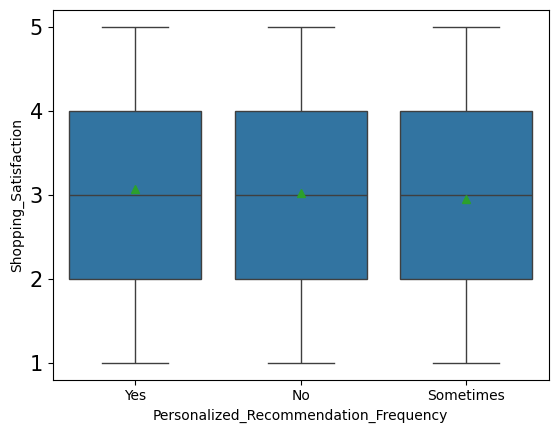

In [116]:
# Identifying trends in how often customers engage with or trust personalized
# recommendations using boxplot:

sns.boxplot(data=df,
            x='Personalized_Recommendation_Frequency',
            y='Shopping_Satisfaction',showmeans = True)

<Axes: xlabel='Segment_kmeans', ylabel='count'>

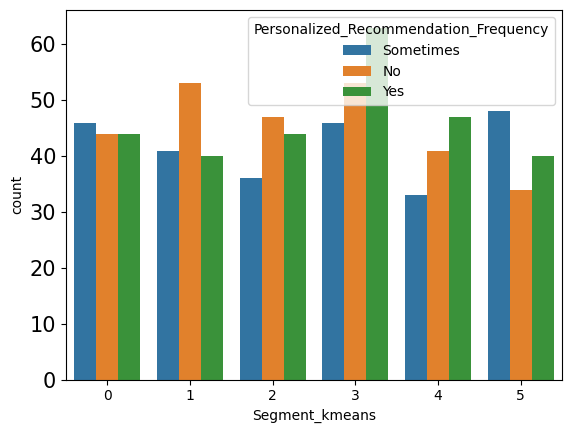

In [117]:
sns.countplot(data=df,
              x='Segment_kmeans',
              hue='Personalized_Recommendation_Frequency')

***Finding Frequent itemsets and Creating Association rules from them***

In [118]:
basket = df['Purchase_Categories'].astype(str).apply(lambda x: [i.strip() for i in x.split(';')])

In [119]:
# Creating transactional-style data from the Purchase Categories column from the data:

transactions = basket.tolist()
# print(transactions)

In [120]:
# Using Onehot encoding for the transactions data:

from mlxtend.preprocessing import TransactionEncoder
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
df_encoded = pd.DataFrame(te_array, columns=te.columns_)
df_encoded

,Beauty and Personal Care,Clothing and Fashion,Groceries and Gourmet Food,Home and Kitchen,others
0,False,True,False,False,False
1,True,False,True,True,False
2,True,True,True,False,True
3,True,True,False,True,False
4,True,True,False,False,True
...,...,...,...,...,...
795,True,True,True,True,True
796,True,True,True,True,True
797,False,False,True,True,False
798,True,True,False,False,True


In [121]:
frequent_itemsets = apriori(df_encoded, min_support = 0.01, use_colnames = True)
print(frequent_itemsets)
print("Total Frequent Itemsets:",frequent_itemsets.shape[0])

    support                                           itemsets
0   0.47875                         (Beauty and Personal Care)
1   0.56250                             (Clothing and Fashion)
2   0.46125                       (Groceries and Gourmet Food)
3   0.48875                                 (Home and Kitchen)
4   0.51500                                           (others)
5   0.25250   (Beauty and Personal Care, Clothing and Fashion)
6   0.20250  (Groceries and Gourmet Food, Beauty and Person...
7   0.20500       (Home and Kitchen, Beauty and Personal Care)
8   0.22500                 (others, Beauty and Personal Care)
9   0.26000  (Groceries and Gourmet Food, Clothing and Fash...
10  0.25625           (Home and Kitchen, Clothing and Fashion)
11  0.30000                     (others, Clothing and Fashion)
12  0.22625     (Home and Kitchen, Groceries and Gourmet Food)
13  0.19750               (Groceries and Gourmet Food, others)
14  0.24250                         (Home and Kitchen, 

In [122]:
# Creating Association rules from the frequent_itemsets:

rules = association_rules(frequent_itemsets, metric = 'confidence',min_threshold= 0.5)
rules = rules[rules['antecedents'].apply(lambda x: len(x)>=1) & rules['consequents'].apply(lambda x: len(x)>=1)]
print(f"Number of Association rules: {rules.shape[0]}")
rules[['antecedents','consequents','support','confidence','lift']].head(10)

Number of Association rules: 23


,antecedents,consequents,support,confidence,lift
0,(Beauty and Personal Care),(Clothing and Fashion),0.25250,0.527415,0.937627
1,(Groceries and Gourmet Food),(Clothing and Fashion),0.26000,0.563686,1.002108
2,(Home and Kitchen),(Clothing and Fashion),0.25625,0.524297,0.932083
3,(others),(Clothing and Fashion),0.30000,0.582524,1.035599
4,(Clothing and Fashion),(others),0.30000,0.533333,1.035599
5,"(Groceries and Gourmet Food, Beauty and Person...",(Clothing and Fashion),0.10500,0.518519,0.921811
6,"(Home and Kitchen, Beauty and Personal Care)",(Clothing and Fashion),0.10625,0.518293,0.921409
7,"(others, Beauty and Personal Care)",(Clothing and Fashion),0.13000,0.577778,1.027160
8,"(Beauty and Personal Care, Clothing and Fashion)",(others),0.13000,0.514851,0.999712
9,"(Home and Kitchen, Groceries and Gourmet Food)",(Clothing and Fashion),0.12125,0.535912,0.952732


***Suggesting actionable insights for improving Amazon’s recommendation system:***

Improving Amazon’s recommendation system requires focusing on customer feedback, behavior patterns, and segment-level insights. Customers who find recommendations helpful show slightly higher satisfaction, meaning Amazon should use “helpfulness” responses to continuously refine personalization. Review reliability also influences rating accuracy, so recommendations should give more weight to trustworthy reviewers. Different customer segments interact with recommendations differently, suggesting the need for segment-specific strategies. High-purchase categories like Clothing, Home & Kitchen, and Beauty should guide cross-category suggestions. Search behavior and cart abandonment data can further improve contextual recommendations. Finally, highlighting trusted reviews and showing relevant, low-price or free-shipping alternatives can increase engagement and boost overall recommendation quality.

# **Task 5: Visualization and Reporting**

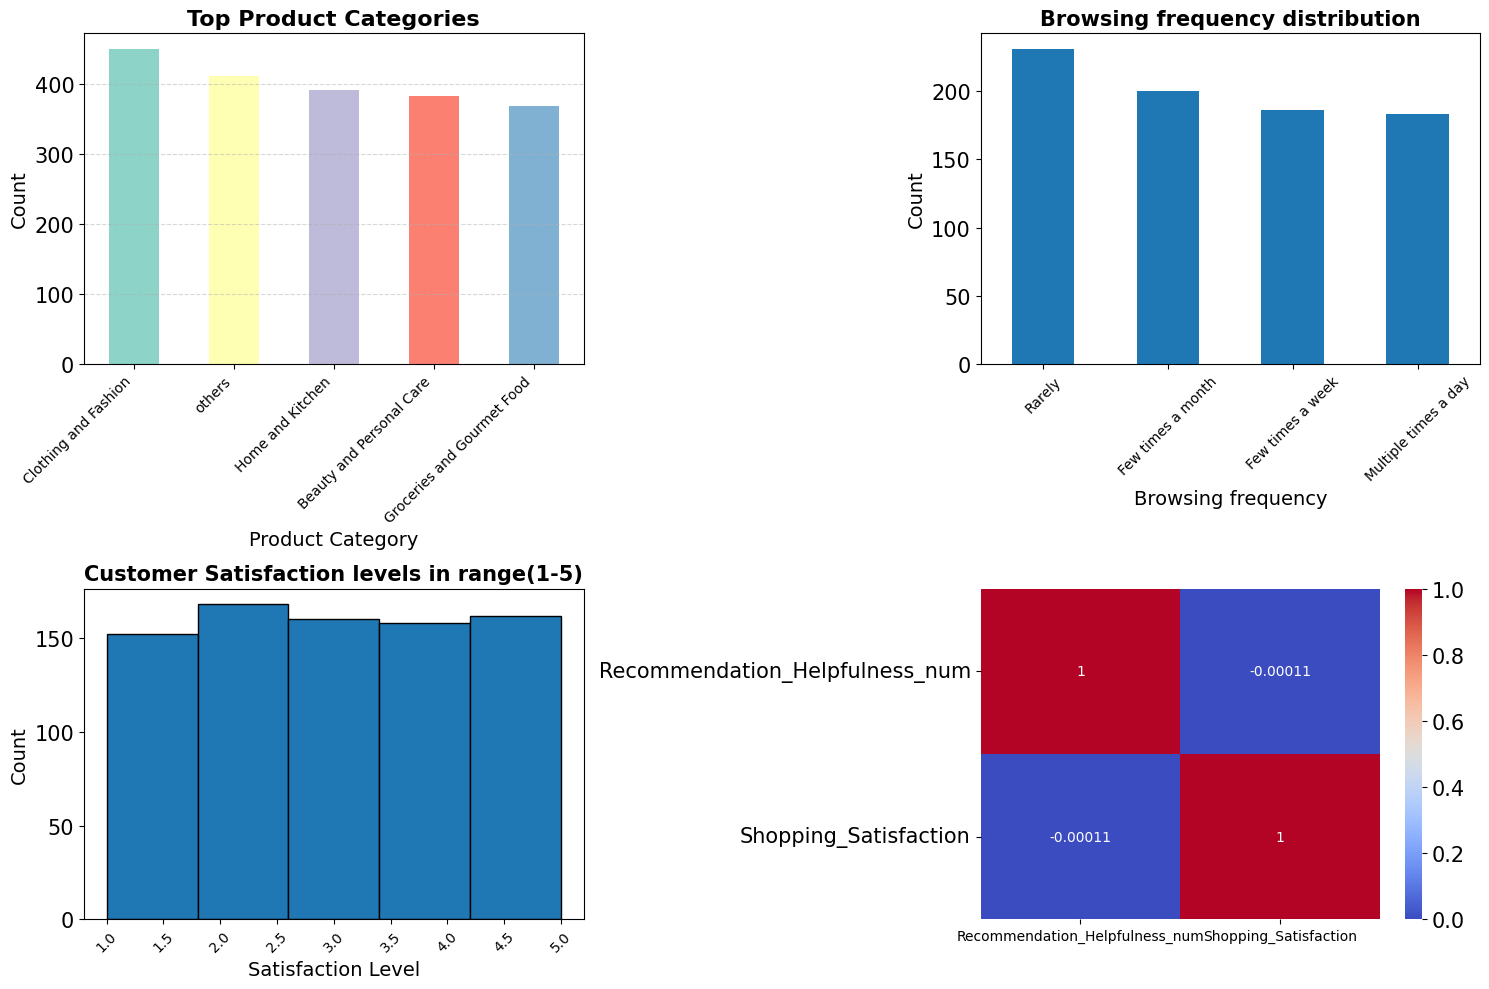

In [123]:
plt.figure(figsize=(15,10))
plt.subplot(2,2,1)
top_categories_counts = df['Purchase_Categories'].str.split(r'[,;]').explode().str.strip().value_counts().head(10)
top_categories_counts.plot(kind='bar',color=plt.cm.Set3(range(10)) )
plt.title("Top Product Categories", fontsize=16, fontweight='bold')
plt.ylabel("Count", fontsize=14)
plt.xlabel("Product Category",fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)


plt.subplot(2,2,2)
browsing_frequency_counts = df['Browsing_Frequency'].str.split(r'[,;]').explode().str.strip().value_counts()
browsing_frequency_counts.plot(kind='bar')
plt.title("Browsing frequency distribution",fontsize = 15,fontweight = 'bold')
plt.ylabel("Count",fontsize = 14)
plt.xlabel("Browsing frequency",fontsize = 14)
plt.xticks(rotation=45)



plt.subplot(2,2,3)
plt.hist(df['Shopping_Satisfaction'], bins=5, edgecolor='black')
plt.title("Customer Satisfaction levels in range(1-5)",fontsize = 15,fontweight = 'bold')
plt.ylabel("Count",fontsize = 14)
plt.xlabel("Satisfaction Level",fontsize = 14)
plt.xticks(rotation=45)


plt.subplot(2,2,4)
corr = df[['Recommendation_Helpfulness_num','Shopping_Satisfaction']].corr()
sns.heatmap(corr, annot=True, cmap = 'coolwarm')
plt.rc('ytick',labelsize = 15)
plt.tight_layout()
plt.show()

# **Task 6: Video Presentation:**

https://www.loom.com/share/dfad186320d5419fa71cb410102db4f4